In [ ]:
# pip install numpy pandas matplotlib tensorflow scikit-learn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
data = pd.read_csv('predict_energy_consumption.csv')
data.head()

,temperature,humidity,wind_speed,solar_irradiance,energy_consumption
0,24.363503,31.107976,5.234114,705.432695,307.398145
1,38.767858,52.514057,4.939576,817.013257,412.444548
2,33.299849,72.376750,18.125092,325.421109,392.072418
3,29.966462,63.933493,4.990924,662.386690,119.254957
4,18.900466,68.393669,5.438995,614.571385,117.162261


In [3]:
X = data[['temperature', 'humidity', 'wind_speed', 'solar_irradiance']].values
y = data['energy_consumption'].values

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),  # Input layer with 64 neurons
    Dense(32, activation='relu'),  # Hidden layer with 32 neurons
    Dense(1,activation='linear')  # Output layer for regression (1 neuron)
])

c:\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(optimizer='adam', loss='mse', metrics=['mse'])  
# Mean Squared Error and Mean Absolute Error

In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,433 (9.50 KB)

 Trainable params: 2,433 (9.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 16530.2637 - mse: 16530.2637 - val_loss: 18161.1582 - val_mse: 18161.1582
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 17009.6953 - mse: 17009.6953 - val_loss: 18033.2148 - val_mse: 18033.2148
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 16981.3320 - mse: 16981.3320 - val_loss: 18102.9355 - val_mse: 18102.9355
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 16563.5430 - mse: 16563.5430 - val_loss: 18021.3086 - val_mse: 18021.3086
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 17501.1719 - mse: 17501.1719 - val_loss: 18026.5977 - val_mse: 18026.5977
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 16429.2832 - mse: 16429.2832 - val_loss: 18051.2461 - val_mse: 18051.2461
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 16693.4746 - mse: 16693.4746 - val_loss: 18079.8828 - val_mse: 18079.8828
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 16808.6348 

In [18]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)
print(f"Test Mean Absolute Error: {test_mae:.2f}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 17694.5352 - mse: 17694.5352  
Test Mean Absolute Error: 17527.63


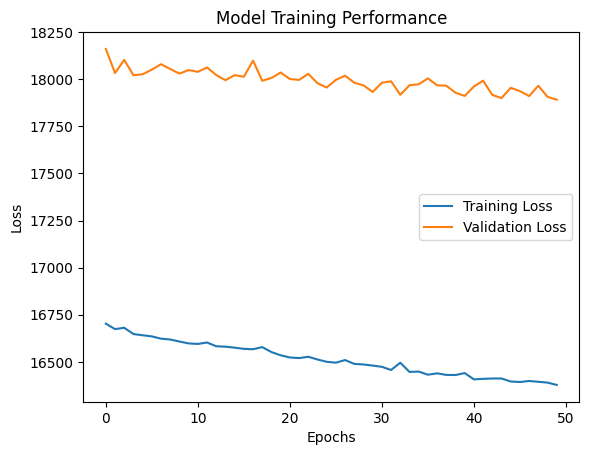

In [19]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Training Performance')
plt.legend()
plt.show()

In [12]:
predictions = model.predict(X_test)
predictions

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


array([[276.8177 ],
       [240.83936],
       [232.60197],
       [187.61298],
       [297.11542],
       [278.96237],
       [290.7013 ],
       [275.2137 ],
       [262.81006],
       [255.51648],
       [246.43707],
       [246.1538 ],
       [277.25995],
       [214.2    ],
       [275.3266 ],
       [288.13055],
       [253.36153],
       [308.2961 ],
       [277.71548],
       [247.20334],
       [256.66425],
       [286.44342],
       [272.99106],
       [261.3114 ],
       [241.75224],
       [229.66344],
       [251.21443],
       [326.3548 ],
       [284.13196],
       [248.61427],
       [223.7177 ],
       [309.1633 ],
       [288.75702],
       [279.8425 ],
       [291.72797],
       [293.6687 ],
       [193.16142],
       [258.822  ],
       [288.47552],
       [233.02321],
       [232.03044],
       [253.00938],
       [233.19646],
       [250.62111],
       [241.31361],
       [255.98631],
       [243.71675],
       [241.79346],
       [265.5288 ],
       [279.07693],


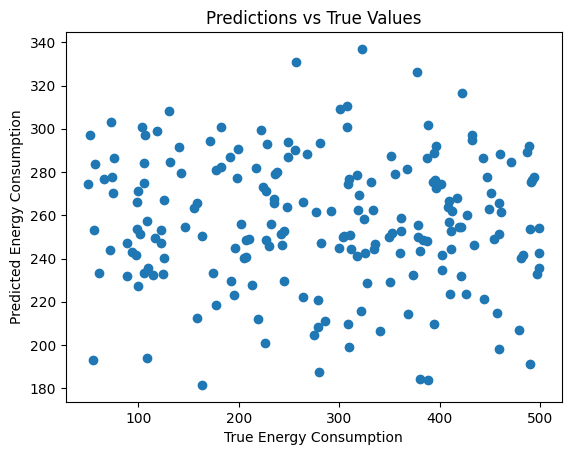

In [13]:
plt.scatter(y_test, predictions)
plt.xlabel('True Energy Consumption')
plt.ylabel('Predicted Energy Consumption')
plt.title('Predictions vs True Values')
plt.show()